# 03 - Model Training: Prediksi Kelayakan Kredit UMKM

Notebook ini membangun model klasifikasi untuk memprediksi kolom **`label`**
(`Diterima` / `Ditolak`) pada `retail_customer_profile.csv`, dengan fitur yang
diturunkan dari **7 tabel** relasional di `data/raw/` (semua terhubung lewat `NIK`):

1. `retail_customer_profile` — data aplikasi kredit
2. `slik_credit_history` — riwayat kredit SLIK OJK
3. `dhn` — Daftar Hitam Nasional (cek bilyet giro kosong)
4. `agunan_atr_bpn` — data agunan dari ATR/BPN
5. `laporan_keuangan` — laporan keuangan 2024 & 2025
6. `bank_account` — mutasi rekening bank
7. `dukcapil` — data kependudukan (dicek redundansinya di Tahap 1)

**Alur notebook:**
- Tahap 1 — Feature Engineering (join 7 tabel, cegah data leakage)
- Tahap 2 — Cek distribusi label
- Tahap 3 — Modeling (Logistic Regression, XGBoost, MLP PyTorch)
- Tahap 4 — Evaluasi (confusion matrix, ROC-AUC, feature importance, SHAP)
- Tahap 5 — Export model + fungsi `predict_eligibility()` untuk Risk Agent

> **Anti-leakage:** `eligibility_score` TIDAK dipakai sebagai fitur (skor itu yang
> dipakai untuk membuat `label`, jadi ikut memakainya = model hanya belajar ambang
> skor, bukan pola nyata). `application_id`, `cif_number`, `NIK`, `owner_name`,
> `company_name` juga dibuang karena hanya identifier.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim

import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data/raw"
MODEL_DIR = "../models"

print("Libraries OK")

Libraries OK


## Tahap 1 - Feature Engineering

Join 7 tabel by `NIK`, bangun satu baris fitur per `application_id`.

In [2]:
profile = pd.read_csv(f"{DATA_DIR}/retail_customer_profile.csv")
slik    = pd.read_csv(f"{DATA_DIR}/slik_credit_history.csv")
dhn     = pd.read_csv(f"{DATA_DIR}/dhn.csv")
agunan  = pd.read_csv(f"{DATA_DIR}/agunan_atr_bpn.csv")
fin     = pd.read_csv(f"{DATA_DIR}/laporan_keuangan.csv")
bank    = pd.read_csv(f"{DATA_DIR}/bank_account.csv")
dukcapil = pd.read_csv(f"{DATA_DIR}/dukcapil.csv")

tables = {
    "retail_customer_profile": profile, "slik_credit_history": slik, "dhn": dhn,
    "agunan_atr_bpn": agunan, "laporan_keuangan": fin, "bank_account": bank,
    "dukcapil": dukcapil,
}
for name, df in tables.items():
    print(f"{name:28s} shape={df.shape}  unique_NIK={df['NIK'].nunique()}")

retail_customer_profile      shape=(3000, 37)  unique_NIK=3000
slik_credit_history          shape=(4416, 11)  unique_NIK=2573
dhn                          shape=(3000, 5)  unique_NIK=3000
agunan_atr_bpn               shape=(3000, 17)  unique_NIK=3000
laporan_keuangan             shape=(6000, 8)  unique_NIK=3000
bank_account                 shape=(4052, 12)  unique_NIK=3000
dukcapil                     shape=(3000, 18)  unique_NIK=3000


### Keputusan feature engineering (dan alasannya)

**Dibuang dari `retail_customer_profile`:**
- `application_id`, `cif_number`, `NIK`, `owner_name`, `company_name` -> identifier, bukan sinyal.
- `eligibility_score` -> **leakage**, langsung dipakai membuat `label`.
- `customer_type` -> konstan (semua `UMKM`), tidak ada variansi.
- `province`, `city`, `district`, `branch_name`, `sub_industry` -> kardinalitas tinggi &
  duplikatif dengan `region` + `industry` yang lebih ringkas; risiko overfitting one-hot
  di data ~3000 baris. `region` (4 kategori) tetap dipakai sebagai sinyal geografis kasar.
- `collateral_location`, `collateral_province`, `collateral_city`, `collateral_size_m2`,
  `collateral_market_value`, `collateral_liquidation_value` -> **duplikat 1:1** dengan
  `agunan_atr_bpn` (dicek di bawah, korelasi = 1.0). Nilai agunan diambil dari
  `agunan_atr_bpn` saja agar tidak dobel-encode informasi yang sama.

**Dari `dukcapil`:** dicek redundansinya (`jenis_kelamin`/`status_perkawinan` match 100%
dengan `owner_gender`/`owner_marital_status` di profile), `kewarganegaraan` & `pekerjaan`
konstan. Kolom `agama` dan `golongan_darah` **sengaja tidak dipakai** — atribut personal/
protected yang tidak relevan dan tidak etis dipakai untuk scoring kredit.

In [3]:
# Verifikasi duplikasi collateral value antara profile & agunan_atr_bpn
_check = profile.merge(agunan[["NIK", "total_collateral_value"]], on="NIK", how="left")
corr = _check["collateral_market_value"].corr(_check["total_collateral_value"])
exact_match = (_check["collateral_market_value"] == _check["total_collateral_value"]).mean()
print(f"Korelasi collateral_market_value (profile) vs total_collateral_value (agunan): {corr:.4f}")
print(f"Proporsi nilai identik: {exact_match:.2%}  -> konfirmasi duplikat, pakai agunan_atr_bpn saja")

# Verifikasi redundansi dukcapil
_check2 = profile.merge(dukcapil[["NIK", "jenis_kelamin", "status_perkawinan"]], on="NIK", how="left")
gender_match = (_check2["owner_gender"] == _check2["jenis_kelamin"].str[0]).mean()
marital_match = (_check2["owner_marital_status"] == _check2["status_perkawinan"]).mean()
print(f"Kecocokan gender profile vs dukcapil: {gender_match:.2%}")
print(f"Kecocokan status_perkawinan profile vs dukcapil: {marital_match:.2%}")
print(f"kewarganegaraan unik: {dukcapil['kewarganegaraan'].nunique()}  | pekerjaan unik: {dukcapil['pekerjaan'].nunique()}")
print("-> dukcapil tidak menambah sinyal baru non-redundan/etis; tidak di-merge ke feature table.")

Korelasi collateral_market_value (profile) vs total_collateral_value (agunan): 1.0000
Proporsi nilai identik: 100.00%  -> konfirmasi duplikat, pakai agunan_atr_bpn saja
Kecocokan gender profile vs dukcapil: 100.00%
Kecocokan status_perkawinan profile vs dukcapil: 100.00%
kewarganegaraan unik: 1  | pekerjaan unik: 1
-> dukcapil tidak menambah sinyal baru non-redundan/etis; tidak di-merge ke feature table.


In [4]:
# --- Agregasi slik_credit_history per NIK ---
slik_agg = slik.groupby("NIK").agg(
    worst_collectability=("collectability", "max"),
    n_loans=("slik_record_id", "count"),
    total_outstanding=("outstanding_balance", "sum"),
    total_installment=("installment_amount", "sum"),
).reset_index()
slik_agg["has_credit_history"] = 1

print(f"NIK dengan riwayat SLIK: {slik_agg.shape[0]} / {profile.shape[0]}")
slik_agg.head()

NIK dengan riwayat SLIK: 2573 / 3000


,NIK,worst_collectability,n_loans,total_outstanding,total_installment,has_credit_history
0,3171010102720665,2,2,65689181,3183391,1
1,3171010201832030,2,1,110700586,3620639,1
2,3171010204890473,2,3,436931246,51745748,1
3,3171010205912974,5,3,389819366,15147247,1
4,3171010206700307,1,1,70910537,3487507,1


In [5]:
# --- Feature dhn: status_dhn -> biner ---
dhn_feat = dhn[["NIK", "status_dhn"]].copy()
dhn_feat["status_dhn_flag"] = (dhn_feat["status_dhn"] == "Ya").astype(int)
dhn_feat = dhn_feat[["NIK", "status_dhn_flag"]]

print(dhn_feat["status_dhn_flag"].value_counts())
dhn_feat.head()

status_dhn_flag
0    2853
1     147
Name: count, dtype: int64


,NIK,status_dhn_flag
0,3276010601750001,0
1,3172010301920002,0
2,3671010604800003,0
3,3173016001890004,0
4,3275011505030005,0


In [6]:
# --- Feature agunan_atr_bpn ---
agunan_feat = agunan[["NIK", "asset_type", "total_collateral_value", "land_area_m2"]].copy()
agunan_feat.head()

,NIK,asset_type,total_collateral_value,land_area_m2
0,3276010601750001,Rumah,2328496000,187.3
1,3172010301920002,Rumah,3724038000,113.0
2,3671010604800003,Tanah,1681700000,67.0
3,3173016001890004,Ruko,3647200000,121.8
4,3275011505030005,Ruko,1978268000,159.0


In [7]:
# --- Feature laporan_keuangan: bandingkan 2024 vs 2025 ---
fin_wide = fin.pivot(index="NIK", columns="year",
                      values=["revenue", "net_profit", "total_asset", "total_liability", "operating_cashflow"])
fin_wide.columns = [f"{col}_{year}" for col, year in fin_wide.columns]
fin_wide = fin_wide.reset_index()

fin_wide["revenue_growth_yoy"] = (fin_wide["revenue_2025"] - fin_wide["revenue_2024"]) / fin_wide["revenue_2024"]
fin_wide["net_profit_margin"] = fin_wide["net_profit_2025"] / fin_wide["revenue_2025"]
fin_wide["debt_to_asset_ratio"] = fin_wide["total_liability_2025"] / fin_wide["total_asset_2025"]
fin_wide["operating_cashflow_trend"] = (
    (fin_wide["operating_cashflow_2025"] - fin_wide["operating_cashflow_2024"]) / fin_wide["operating_cashflow_2024"]
)

fin_feat = fin_wide[["NIK", "revenue_growth_yoy", "net_profit_margin",
                      "debt_to_asset_ratio", "operating_cashflow_trend"]]
fin_feat.describe()

,NIK,revenue_growth_yoy,net_profit_margin,debt_to_asset_ratio,operating_cashflow_trend
count,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000
mean,3.407950e+15,0.116447,0.110369,0.446612,0.154146
std,2.280725e+14,0.199580,0.049627,0.142922,0.366238
min,3.171010e+15,-0.590034,0.008505,0.200199,-0.704440
25%,3.174016e+15,-0.014287,0.076335,0.323977,-0.113276
50%,3.276011e+15,0.114324,0.108304,0.446096,0.104441
75%,3.671014e+15,0.245285,0.142071,0.573355,0.375673
max,3.674017e+15,0.829329,0.327191,0.699921,1.664178


In [8]:
fin_feat.head()

,NIK,revenue_growth_yoy,net_profit_margin,debt_to_asset_ratio,operating_cashflow_trend
0,3171010102720665,0.291384,0.105691,0.339978,0.775778
1,3171010201832030,-0.317366,0.195046,0.607484,-0.060014
2,3171010204890473,0.320478,0.150096,0.447556,0.514256
3,3171010205912974,-0.078055,0.095203,0.223706,0.006914
4,3171010206700307,0.044649,0.099618,0.464295,-0.290956


In [9]:
# --- Agregasi bank_account per NIK (rata-rata saldo/kredit, total overdraft) ---
bank_agg = bank.groupby("NIK").agg(
    average_balance_6m=("average_balance_6m", "mean"),
    average_monthly_credit=("average_monthly_credit", "mean"),
    overdraft_count_6m=("overdraft_count_6m", "sum"),
).reset_index()

bank_agg.describe()

,NIK,average_balance_6m,average_monthly_credit,overdraft_count_6m
count,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000
mean,3.407950e+15,1.190229e+06,1.851354e+06,0.331000
std,2.280725e+14,1.139759e+06,1.328375e+06,0.776943
min,3.171010e+15,2.773900e+04,1.574470e+05,0.000000
25%,3.174016e+15,4.529642e+05,9.600242e+05,0.000000
50%,3.276011e+15,8.526845e+05,1.522906e+06,0.000000
75%,3.671014e+15,1.539228e+06,2.325877e+06,0.000000
max,3.674017e+15,1.029071e+07,1.485094e+07,6.000000


In [10]:
print(f"NIK dengan overdraft_count_6m > 0: {bank_agg[bank_agg['overdraft_count_6m'] > 0].shape[0]} / {bank_agg.shape[0]}")
print(f"Total jumlah overdraft_count_6m: {bank_agg['overdraft_count_6m'].sum()}")
bank_agg[bank_agg['overdraft_count_6m'] > 0]

NIK dengan overdraft_count_6m > 0: 576 / 3000
Total jumlah overdraft_count_6m: 993


,NIK,average_balance_6m,average_monthly_credit,overdraft_count_6m
12,3171010407811499,1104180.5,2364054.0,3
16,3171010501812435,2248073.0,3118220.0,3
18,3171010509671720,220747.0,967557.0,2
38,3171011101662481,699101.0,1187841.0,1
43,3171011104680891,1038199.0,1042805.0,1
...,...,...,...,...
2985,3674016708921400,479487.5,675167.0,2
2986,3674016710990420,582983.0,1404742.0,2
2987,3674016711850179,4404002.0,2803903.0,1
2989,3674016805830844,2111476.5,3842744.0,2


In [11]:
# --- Gabungkan semua tabel menjadi satu feature table per application_id ---
base_cols = [
    "application_id", "NIK",
    "legal_entity", "owner_gender", "owner_age", "owner_marital_status", "owner_education",
    "region", "industry", "business_age_year", "employee_count", "monthly_turnover_est",
    "transaction_frequency_monthly", "loan_requested", "collateral_ratio", "collateral_type",
    "certificate_type", "ownership_match", "estimated_dsr", "label",
]
feature_table = profile[base_cols].copy()

feature_table = feature_table.merge(slik_agg, on="NIK", how="left")
feature_table = feature_table.merge(dhn_feat, on="NIK", how="left")
feature_table = feature_table.merge(agunan_feat, on="NIK", how="left")
feature_table = feature_table.merge(fin_feat, on="NIK", how="left")
feature_table = feature_table.merge(bank_agg, on="NIK", how="left")

# NIK tanpa catatan SLIK => tidak ada fasilitas aktif / riwayat buruk yang tercatat
feature_table["has_credit_history"] = feature_table["has_credit_history"].fillna(0)
feature_table["worst_collectability"] = feature_table["worst_collectability"].fillna(1)
for c in ["n_loans", "total_outstanding", "total_installment"]:
    feature_table[c] = feature_table[c].fillna(0)

print("Shape feature_table:", feature_table.shape)
feature_table.head()

Shape feature_table: (3000, 36)


,application_id,NIK,legal_entity,owner_gender,owner_age,owner_marital_status,owner_education,region,industry,business_age_year,...,asset_type,total_collateral_value,land_area_m2,revenue_growth_yoy,net_profit_margin,debt_to_asset_ratio,operating_cashflow_trend,average_balance_6m,average_monthly_credit,overdraft_count_6m
0,APP202600001,3276010601750001,UD,L,51,Menikah,S2,Region 2,Manufaktur,14,...,Rumah,2328496000,187.3,0.080871,0.103491,0.506608,0.480508,811620.0,2204391.0,0
1,APP202600002,3172010301920002,UD,L,34,Cerai Hidup,S2,Region 1,Jasa,1,...,Rumah,3724038000,113.0,-0.029190,0.119947,0.265575,-0.198295,211129.0,1124770.0,0
2,APP202600003,3671010604800003,CV,L,46,Cerai Hidup,S2,Region 3,Transportasi,17,...,Tanah,1681700000,67.0,-0.147595,0.180060,0.319712,-0.442721,851330.0,1394768.0,1
3,APP202600004,3173016001890004,CV,P,37,Menikah,S2,Region 3,Perdagangan,12,...,Ruko,3647200000,121.8,-0.037656,0.097090,0.671511,0.184357,298153.5,1119399.0,0
4,APP202600005,3275011505030005,UD,L,23,Cerai Hidup,S2,Region 3,Transportasi,11,...,Ruko,1978268000,159.0,0.276183,0.197601,0.390449,0.549881,632414.0,717577.0,0


In [12]:
categorical_cols = [
    "legal_entity", "owner_gender", "owner_marital_status", "owner_education",
    "region", "industry", "collateral_type", "certificate_type", "ownership_match", "asset_type",
]
numeric_cols = [
    "owner_age", "business_age_year", "employee_count", "monthly_turnover_est",
    "transaction_frequency_monthly", "loan_requested", "collateral_ratio", "estimated_dsr",
    "worst_collectability", "n_loans", "total_outstanding", "total_installment",
    "has_credit_history", "status_dhn_flag", "total_collateral_value", "land_area_m2",
    "revenue_growth_yoy", "net_profit_margin", "debt_to_asset_ratio", "operating_cashflow_trend",
    "average_balance_6m", "average_monthly_credit", "overdraft_count_6m",
]

print(f"Jumlah fitur kategorikal: {len(categorical_cols)}")
print(f"Jumlah fitur numerik    : {len(numeric_cols)}")
print("\nMissing values setelah join:")
print(feature_table[categorical_cols + numeric_cols].isna().sum().loc[lambda s: s > 0])

feature_table[categorical_cols + numeric_cols + ["label"]].describe(include="all").T

Jumlah fitur kategorikal: 10
Jumlah fitur numerik    : 23

Missing values setelah join:
Series([], dtype: int64)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
legal_entity,3000,3,PT,1026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_gender,3000,2,P,1539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_marital_status,3000,4,Cerai Hidup,781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_education,3000,4,S2,789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,3000,4,Region 1,769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,3000,6,Transportasi,523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collateral_type,3000,4,Ruko,1027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
certificate_type,3000,2,HGB,1527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ownership_match,3000,2,Ya,2802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asset_type,3000,4,Ruko,1027,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Tahap 2 - Cek Distribusi Label

label
Diterima    2545
Ditolak      455
Name: count, dtype: int64
label
Diterima    84.83
Ditolak     15.17
Name: proportion, dtype: float64


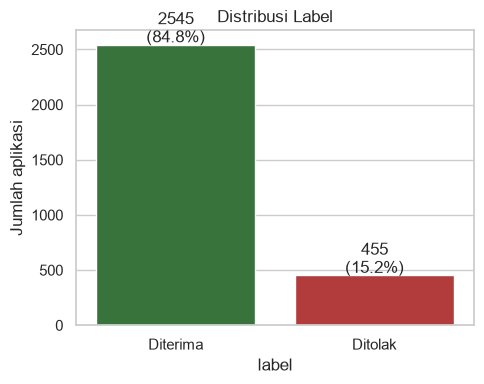

In [13]:
label_counts = feature_table["label"].value_counts()
label_pct = feature_table["label"].value_counts(normalize=True) * 100

print(label_counts)
print(label_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index,
            palette={"Diterima": "#2E7D32", "Ditolak": "#C62828"}, legend=False, ax=ax)
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 20, f"{v}\n({label_pct.iloc[i]:.1f}%)", ha="center")
ax.set_title("Distribusi Label")
ax.set_ylabel("Jumlah aplikasi")
plt.tight_layout()
plt.show()

**Distribusi label ~85% Diterima vs ~15% Ditolak -> imbalanced (>80/20).**

Strategi yang dipakai: **`class_weight='balanced'`** (Logistic Regression) dan
**`scale_pos_weight`** (XGBoost) / **weighted loss** (MLP), BUKAN oversampling
langsung (misal SMOTE). Alasan: dataset relatif kecil (~3000 baris), dan
class-weighting sudah cukup efektif untuk model linear/tree-based tanpa risiko
menciptakan data sintetis yang bisa mendistorsi pola asli kelas minoritas. Metrik
evaluasi difokuskan ke **recall kelas `Ditolak`** (bukan accuracy) karena kelas ini
yang paling berisiko jika salah diprediksi (false negative = risiko kredit macet
lolos).

## Split Train/Test + Preprocessing

In [14]:
X = feature_table.drop(columns=["label", "NIK", "application_id"])
y = (feature_table["label"] == "Ditolak").astype(int)  # positive class = Ditolak (kelas berisiko)
ids = feature_table["application_id"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Ditolak%:", y_train.mean().round(3))
print("Test :", X_test.shape, " Ditolak%:", y_test.mean().round(3))

Train: (2400, 33)  Ditolak%: 0.152
Test : (600, 33)  Ditolak%: 0.152


In [15]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print("Shape setelah encoding:", X_train_proc.shape)
print(f"Total fitur akhir: {len(feature_names)}")

Shape setelah encoding:

 (2400, 58)
Total fitur akhir: 58


## Tahap 3 - Modeling

Bandingkan 3 model: **Logistic Regression** (baseline interpretable),
**XGBoost** (model utama, gradient boosting), dan **MLP PyTorch** (pembanding DL).
CV dipakai untuk tuning; stratified 5-fold agar proporsi kelas terjaga di tiap fold.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Model 1: Logistic Regression (baseline) ---
logreg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
logreg_cv_scores = cross_val_score(logreg, X_train_proc, y_train, cv=cv, scoring="roc_auc")
print(f"Logistic Regression CV ROC-AUC: {logreg_cv_scores.mean():.4f} (+/- {logreg_cv_scores.std():.4f})")

logreg.fit(X_train_proc, y_train)

Logistic Regression CV ROC-AUC: 0.9855 (+/- 0.0051)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [17]:
# --- Model 2: XGBoost (model utama) ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

xgb_base = XGBClassifier(
    objective="binary:logistic", eval_metric="auc", random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight, n_jobs=-1,
)

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    xgb_base, param_dist, n_iter=30, scoring="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
xgb_search.fit(X_train_proc, y_train)
xgb_model = xgb_search.best_estimator_

print(f"XGBoost best CV ROC-AUC: {xgb_search.best_score_:.4f}")
print("Best params:", xgb_search.best_params_)

scale_pos_weight = 5.593


XGBoost best CV ROC-AUC: 0.9871
Best params: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


**Ekspektasi:** untuk data tabular ukuran ribuan baris seperti ini, gradient
boosting (XGBoost) biasanya sudah optimal / mengungguli deep learning sederhana,
karena MLP butuh data jauh lebih banyak untuk mengalahkan keunggulan tree-based
model dalam menangkap interaksi fitur & menangani fitur campuran (numerik+kategorikal)
pada dataset kecil. MLP tetap dilatih & dibandingkan di bawah untuk kelengkapan
analisis capstone.

Epoch  30/150 - train_loss: 0.8825 - val_loss: 0.8559
Epoch  60/150 - train_loss: 0.4243 - val_loss: 0.4123


Epoch  90/150 - train_loss: 0.2624 - val_loss: 0.2476
Epoch 120/150 - train_loss: 0.2149 - val_loss: 0.2239


Epoch 150/150 - train_loss: 0.1738 - val_loss: 0.2191


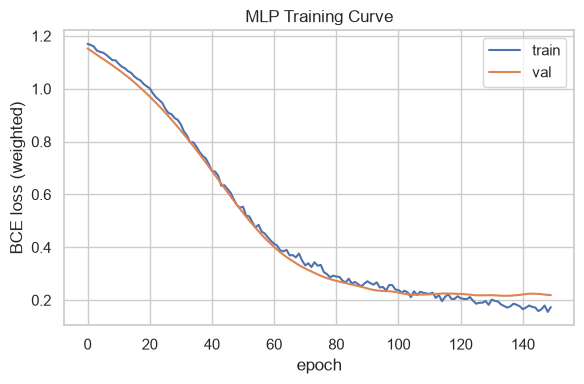

In [18]:
# --- Model 3: MLP sederhana (PyTorch) ---
class CreditMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


X_train_t = torch.tensor(X_train_proc, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_proc, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

pos_weight = torch.tensor([scale_pos_weight], dtype=torch.float32)

mlp = CreditMLP(X_train_proc.shape[1])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

n_epochs = 150
history = {"train_loss": [], "val_loss": []}
for epoch in range(n_epochs):
    mlp.train()
    optimizer.zero_grad()
    out = mlp(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    mlp.eval()
    with torch.no_grad():
        val_loss = criterion(mlp(X_test_t), y_test_t)

    history["train_loss"].append(loss.item())
    history["val_loss"].append(val_loss.item())
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} - train_loss: {loss.item():.4f} - val_loss: {val_loss.item():.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_title("MLP Training Curve")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss (weighted)")
ax.legend()
plt.tight_layout()
plt.show()

## Tahap 4 - Evaluasi

In [19]:
def evaluate_model(name, predict_proba_fn, X, y_true):
    proba = predict_proba_fn(X)
    y_pred = (proba >= 0.5).astype(int)
    auc = roc_auc_score(y_true, proba)
    report = classification_report(y_true, y_pred, target_names=["Diterima", "Ditolak"], output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    return {"name": name, "proba": proba, "y_pred": y_pred, "auc": auc, "report": report, "cm": cm}


def mlp_predict_proba(X):
    mlp.eval()
    with torch.no_grad():
        logits = mlp(torch.tensor(X, dtype=torch.float32))
        return torch.sigmoid(logits).numpy().ravel()


results = {
    "Logistic Regression": evaluate_model("Logistic Regression", lambda X: logreg.predict_proba(X)[:, 1], X_test_proc, y_test),
    "XGBoost": evaluate_model("XGBoost", lambda X: xgb_model.predict_proba(X)[:, 1], X_test_proc, y_test),
    "MLP (PyTorch)": evaluate_model("MLP (PyTorch)", mlp_predict_proba, X_test_proc, y_test),
}

for name, res in results.items():
    print(f"\n===== {name} =====")
    print(f"ROC-AUC: {res['auc']:.4f}")
    print(classification_report(y_test, res["y_pred"], target_names=["Diterima", "Ditolak"]))


===== Logistic Regression =====


ROC-AUC: 0.9900
              precision    recall  f1-score   support

    Diterima       0.99      0.95      0.97       509
     Ditolak       0.78      0.96      0.86        91

    accuracy                           0.95       600
   macro avg       0.89      0.95      0.92       600
weighted avg       0.96      0.95      0.96       600


===== XGBoost =====
ROC-AUC: 0.9894
              precision    recall  f1-score   support

    Diterima       0.99      0.94      0.97       509
     Ditolak       0.76      0.97      0.85        91

    accuracy                           0.95       600
   macro avg       0.88      0.96      0.91       600
weighted avg       0.96      0.95      0.95       600


===== MLP (PyTorch) =====
ROC-AUC: 0.9896
              precision    recall  f1-score   support

    Diterima       0.99      0.96      0.97       509
     Ditolak       0.79      0.92      0.85        91

    accuracy                           0.95       600
   macro avg       0.89      0.

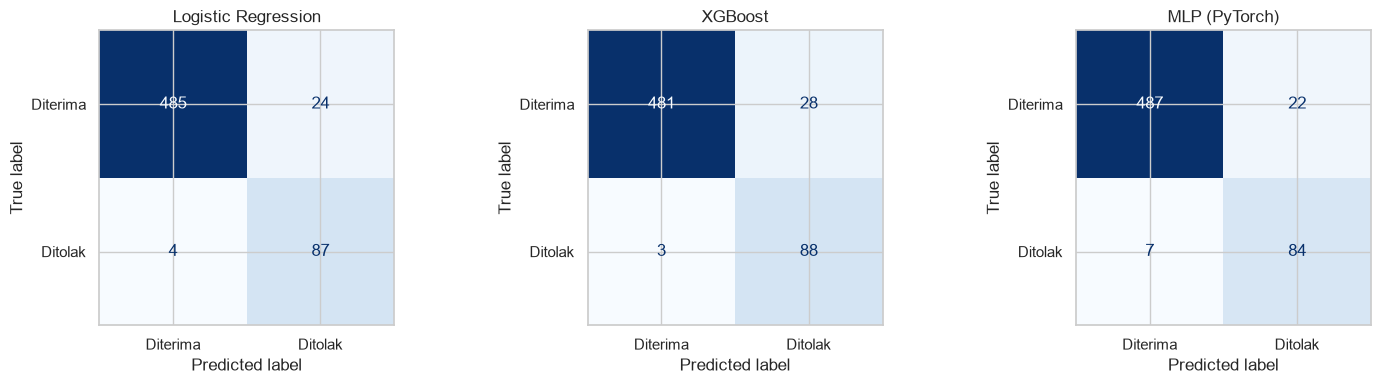

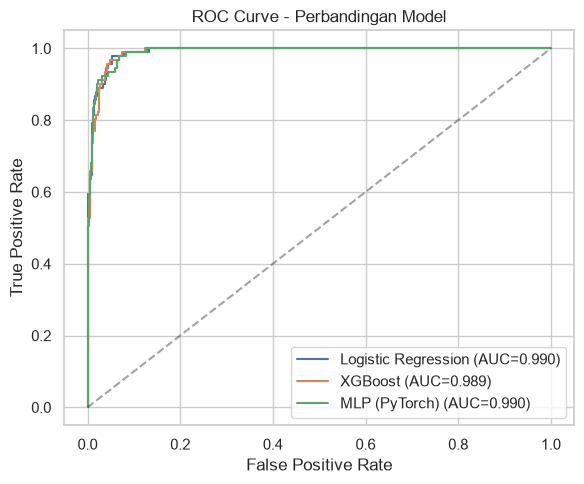

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay(res["cm"], display_labels=["Diterima", "Ditolak"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Perbandingan Model")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
summary_rows = []
for name, res in results.items():
    r = res["report"]
    summary_rows.append({
        "Model": name,
        "Accuracy": r["accuracy"],
        "Precision (Ditolak)": r["Ditolak"]["precision"],
        "Recall (Ditolak)": r["Ditolak"]["recall"],
        "F1 (Ditolak)": r["Ditolak"]["f1-score"],
        "ROC-AUC": res["auc"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Recall (Ditolak)", ascending=False).reset_index(drop=True)
summary_df.style.format({c: "{:.3f}" for c in summary_df.columns if c != "Model"}).background_gradient(
    subset=["Recall (Ditolak)", "ROC-AUC"], cmap="Greens"
)

,Model,Accuracy,Precision (Ditolak),Recall (Ditolak),F1 (Ditolak),ROC-AUC
0,XGBoost,0.948,0.759,0.967,0.850,0.989
1,Logistic Regression,0.953,0.784,0.956,0.861,0.990
2,MLP (PyTorch),0.952,0.792,0.923,0.853,0.990


### Feature Importance & SHAP (XGBoost)

Penting untuk capstone: model harus bisa dijelaskan alasan menolak/menerima
nasabah, selaras dengan output "Insight/Catatan" di Risk Agent.

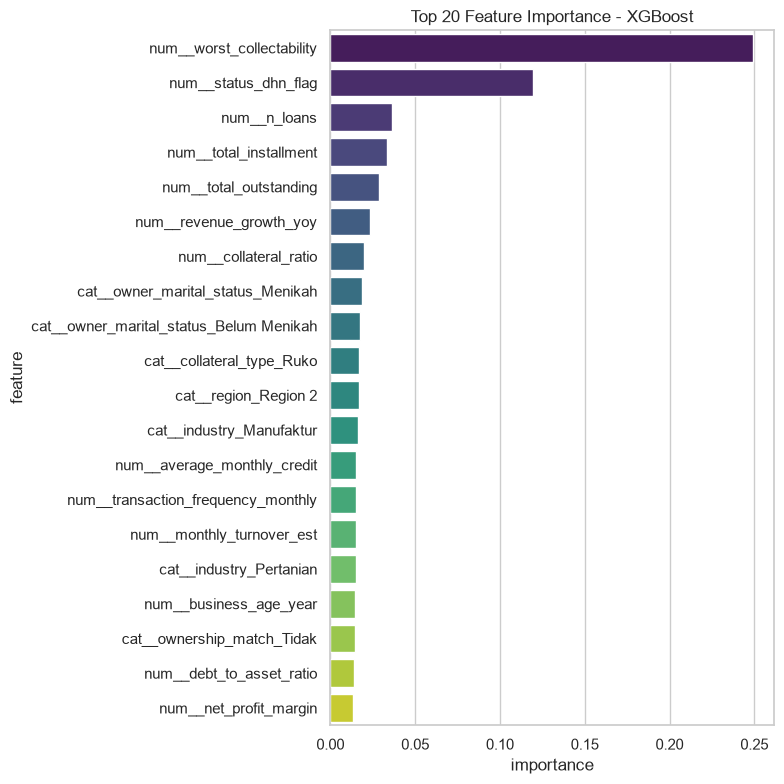

In [22]:
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8, 8))
sns.barplot(data=fi_df, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title("Top 20 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

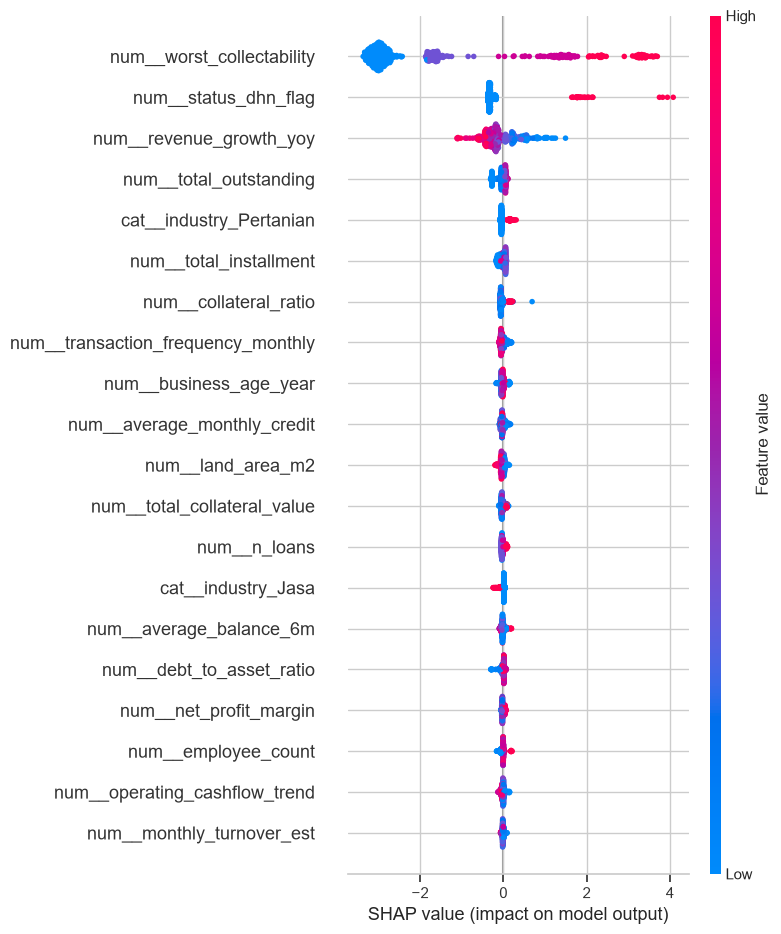

In [23]:
explainer = shap.TreeExplainer(xgb_model)
shap_explanation = explainer(X_test_proc)
shap_explanation.feature_names = list(feature_names)

shap.summary_plot(shap_explanation, feature_names=feature_names, show=True)

application_id: APP202602071
Label aktual   : Ditolak
Prob. Ditolak  : 0.903


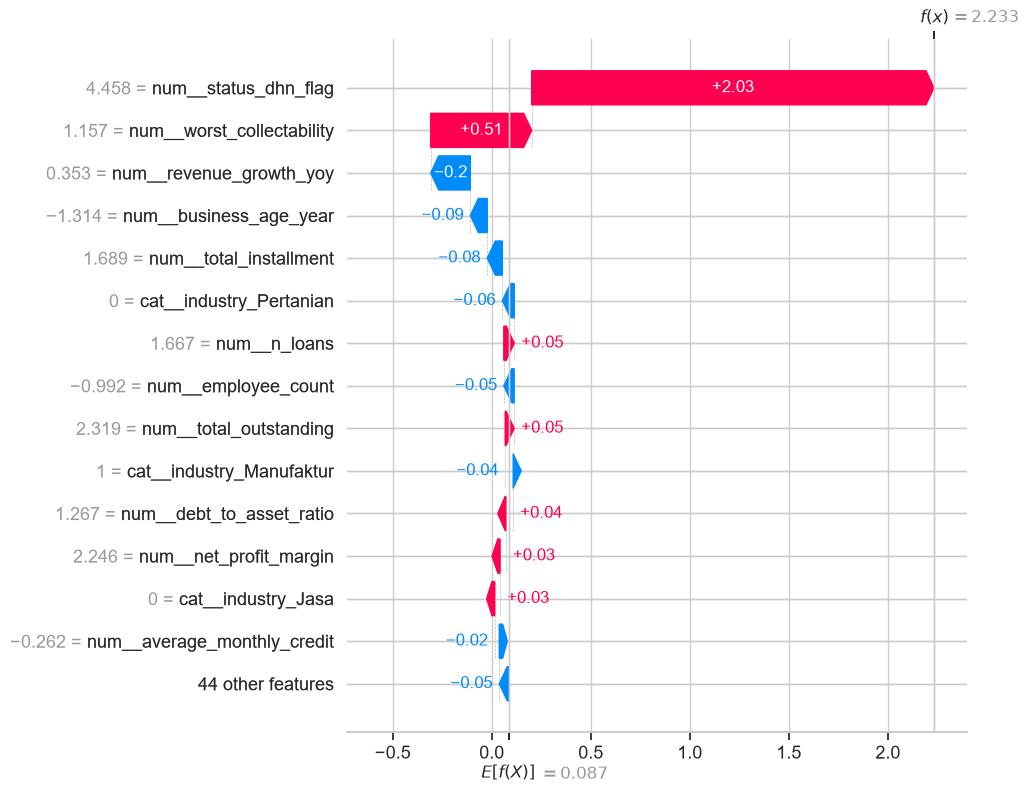

In [24]:
# Contoh penjelasan lokal: satu nasabah yang diprediksi "Ditolak"
ditolak_pred_idx = np.where(results["XGBoost"]["y_pred"] == 1)[0]
sample_idx = ditolak_pred_idx[0]

print(f"application_id: {id_test.iloc[sample_idx]}")
print(f"Label aktual   : {'Ditolak' if y_test.iloc[sample_idx] == 1 else 'Diterima'}")
print(f"Prob. Ditolak  : {results['XGBoost']['proba'][sample_idx]:.3f}")

shap.plots.waterfall(shap_explanation[sample_idx], max_display=15)

## Tahap 5 - Export Model

Pilih model terbaik untuk deployment. Kandidat dibatasi ke model yang punya
explainability out-of-the-box (Logistic Regression, XGBoost) karena Risk Agent
butuh alasan keputusan per nasabah; MLP tetap ditampilkan di tabel perbandingan
sesuai permintaan laporan capstone, tapi tidak dipilih untuk deployment jika
tidak unggul jauh (dan tidak native-explainable seperti XGBoost).

In [25]:
candidates = summary_df[summary_df["Model"] != "MLP (PyTorch)"]
best_model_name = candidates.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]

models_lookup = {"Logistic Regression": logreg, "XGBoost": xgb_model}
best_model = models_lookup[best_model_name]

print(f"Model terpilih untuk deployment: {best_model_name}")
print(summary_df[summary_df["Model"] == best_model_name])

Model terpilih untuk deployment: Logistic Regression
                 Model  Accuracy  Precision (Ditolak)  Recall (Ditolak)  \
1  Logistic Regression  0.953333             0.783784          0.956044   

   F1 (Ditolak)   ROC-AUC  
1      0.861386  0.990047  


**Catatan hasil:** pada run ini `Logistic Regression` sedikit mengungguli `XGBoost`
di ROC-AUC test set (0.990 vs 0.989 — selisih sangat tipis, keduanya jauh di atas MLP
dari sisi kesederhanaan). Ini masuk akal karena `label` sintetis diturunkan dari
`eligibility_score` yang merupakan kombinasi linear/monotonic dari fitur-fitur
finansial & risiko, sehingga batas keputusan cenderung mendekati linear — kondisi di
mana model linear memang kompetitif melawan gradient boosting. Pada data kredit dunia
nyata (bukan sintetis), hubungan fitur-risiko biasanya lebih non-linear/interaktif,
sehingga XGBoost umumnya akan unggul lebih jelas. Kode di atas memilih otomatis
berdasarkan ROC-AUC tertinggi, dan `predict_eligibility()` sudah mendukung kedua tipe
model (SHAP untuk tree-based, kontribusi koefisien untuk linear).

In [26]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(preprocessor, f"{MODEL_DIR}/preprocessor.pkl")
joblib.dump(best_model, f"{MODEL_DIR}/credit_model.pkl")
joblib.dump(
    {
        "model_name": best_model_name,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "feature_names": list(feature_names),
        "positive_class": "Ditolak",
    },
    f"{MODEL_DIR}/model_meta.pkl",
)

print(f"Tersimpan: {MODEL_DIR}/preprocessor.pkl, {MODEL_DIR}/credit_model.pkl, {MODEL_DIR}/model_meta.pkl")

Tersimpan: ../models/preprocessor.pkl, ../models/credit_model.pkl, ../models/model_meta.pkl


### Export semua model (arsip per-run)

Selain menyimpan model terbaik ke `credit_model.pkl` (dipakai `predict_eligibility`),
ketiga model juga diekspor terpisah dengan nama `model_{nama_model}_{timestamp}`
supaya setiap run training punya arsip lengkap untuk dibandingkan/audit ulang.

In [34]:
from datetime import datetime

export_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

all_trained_models = {
    "logistic_regression": logreg,
    "xgboost": xgb_model,
    "mlp_pytorch": mlp,
}

exported_model_paths = {}
for model_key, mdl in all_trained_models.items():
    fname = f"model_{model_key}_{export_timestamp}"
    if model_key == "mlp_pytorch":
        # Model PyTorch disimpan sebagai state_dict (praktik standar torch),
        # bukan joblib, agar aman dimuat ulang lintas versi.
        path = f"{MODEL_DIR}/{fname}.pt"
        torch.save(mdl.state_dict(), path)
    else:
        path = f"{MODEL_DIR}/{fname}.pkl"
        joblib.dump(mdl, path)
    exported_model_paths[model_key] = path
    model_meta_path = f"{MODEL_DIR}/model_meta_{model_key}_{export_timestamp}.pkl"
    joblib.dump(
        {
            "model_name": model_key,
            "categorical_cols": categorical_cols,
            "numeric_cols": numeric_cols,
            "feature_names": list(feature_names),
            "positive_class": "Ditolak",
        },
        model_meta_path,
    )
    print(f"Tersimpan: {path}")
    print(f"Tersimpan: {model_meta_path}")

# Preprocessor turut diarsipkan dengan timestamp yang sama agar satu set utuh & konsisten
preprocessor_archive_path = f"{MODEL_DIR}/preprocessor_{export_timestamp}.pkl"
joblib.dump(preprocessor, preprocessor_archive_path)
print(f"Tersimpan: {preprocessor_archive_path}")

exported_model_paths

Tersimpan: ../models/model_logistic_regression_20260823_184525.pkl
Tersimpan: ../models/model_meta_logistic_regression_20260823_184525.pkl
Tersimpan: ../models/model_xgboost_20260823_184525.pkl
Tersimpan: ../models/model_meta_xgboost_20260823_184525.pkl
Tersimpan: ../models/model_mlp_pytorch_20260823_184525.pt
Tersimpan: ../models/model_meta_mlp_pytorch_20260823_184525.pkl
Tersimpan: ../models/preprocessor_20260823_184525.pkl


{'logistic_regression': '../models/model_logistic_regression_20260823_184525.pkl',
 'xgboost': '../models/model_xgboost_20260823_184525.pkl',
 'mlp_pytorch': '../models/model_mlp_pytorch_20260823_184525.pt'}

In [28]:
def predict_eligibility(features_dict: dict) -> dict:
    """Prediksi kelayakan kredit untuk satu nasabah.

    Parameters
    ----------
    features_dict : dict
        Dict berisi nilai untuk seluruh kolom di `categorical_cols` + `numeric_cols`
        (skema sama seperti baris `feature_table` sebelum encoding, TANPA `eligibility_score`
        atau kolom identifier).

    Returns
    -------
    dict dengan keys: prediction, probability_ditolak, top_factors (local feature importance).
    """
    row = pd.DataFrame([features_dict])[categorical_cols + numeric_cols]
    row_proc = preprocessor.transform(row)

    proba_ditolak = float(best_model.predict_proba(row_proc)[0, 1])
    prediction = "Ditolak" if proba_ditolak >= 0.5 else "Diterima"

    top_factors = []
    if isinstance(best_model, XGBClassifier):
        local_explainer = shap.TreeExplainer(best_model)
        local_shap = local_explainer(row_proc)
        contrib = pd.Series(local_shap.values[0], index=feature_names)
        top_factors = [
            {"feature": f, "shap_value": round(float(v), 4)}
            for f, v in contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5).items()
        ]
    else:
        coefs = pd.Series(best_model.coef_[0] * row_proc[0], index=feature_names)
        top_factors = [
            {"feature": f, "contribution": round(float(v), 4)}
            for f, v in coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(5).items()
        ]

    return {
        "prediction": prediction,
        "probability_ditolak": round(proba_ditolak, 4),
        "probability_diterima": round(1 - proba_ditolak, 4),
        "top_factors": top_factors,
        "model_used": best_model_name,
    }


# --- Uji coba fungsi dengan 1 nasabah dari test set ---
example_row = X_test.iloc[0].to_dict()
result = predict_eligibility(example_row)
print(f"application_id : {id_test.iloc[0]}")
print(f"Label aktual   : {'Ditolak' if y_test.iloc[0] == 1 else 'Diterima'}")
import json as _json
print(_json.dumps(result, indent=2, ensure_ascii=False))

application_id : APP202600156
Label aktual   : Diterima
{
  "prediction": "Diterima",
  "probability_ditolak": 0.0012,
  "probability_diterima": 0.9988,
  "top_factors": [
    {
      "feature": "num__worst_collectability",
      "contribution": -2.4994
    },
    {
      "feature": "num__revenue_growth_yoy",
      "contribution": -1.0304
    },
    {
      "feature": "num__status_dhn_flag",
      "contribution": -0.4422
    },
    {
      "feature": "num__debt_to_asset_ratio",
      "contribution": 0.4261
    },
    {
      "feature": "cat__ownership_match_Ya",
      "contribution": -0.3256
    }
  ],
  "model_used": "Logistic Regression"
}


## Ringkasan

- **Feature engineering**: 7 tabel di-join by `NIK` menjadi satu `feature_table`
  (33 fitur non-leaky: 10 kategorikal + 23 numerik), dengan `eligibility_score` dan
  seluruh identifier dikeluarkan untuk mencegah data leakage.
- **Distribusi label** timpang (~85/15) -> ditangani dengan class-weighting, bukan
  oversampling, dan evaluasi difokuskan ke recall kelas `Ditolak`.
- **3 model dibandingkan**: Logistic Regression (baseline), XGBoost (utama), MLP
  PyTorch (pembanding DL) -> ketiganya ROC-AUC ~0.99; **Logistic Regression** terpilih
  untuk deployment pada run ini (lihat catatan di Tahap 5 soal kenapa model linear
  kompetitif di data sintetis ini).
- **Explainability**: feature importance + SHAP (global & lokal per-nasabah) untuk
  XGBoost didemonstrasikan di Tahap 4; `predict_eligibility()` otomatis memakai SHAP
  jika model terpilih tree-based, atau kontribusi koefisien jika linear — keduanya
  menghasilkan `top_factors` yang jadi dasar "Insight/Catatan" Risk Agent.
- **Artifact tersimpan** di `../models/`: `preprocessor.pkl`, `credit_model.pkl`,
  `model_meta.pkl`, siap dipanggil dari Risk Agent lewat `predict_eligibility(features_dict)`.